## Данные

В этой лабораторной работе будем работать с [датасетом](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset), предназначенным для обучения алгоритма рекомендаций книг.

Для рекомендаций нам понадобятся таблицы `Books.csv` и `Ratings.scv`. Файл с рейтингами можно найти в папке с лабораторной работой на гитхабе. Файл с описаниями книг слишком большой, поэтому он располагается только по ссылке:
1. Файл с рейтингами (такой же, как в гитхабе): https://drive.google.com/file/d/1Hliaee7Y584-7lMoGeGjGabRRubzdoYn/view?usp=sharing
2. Файл с книгами:  https://drive.google.com/file/d/1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy/view?usp=sharing

In [440]:
import pandas as pd

In [441]:
!gdown 1Hliaee7Y584-7lMoGeGjGabRRubzdoYn
!gdown 1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy

Downloading...
From: https://drive.google.com/uc?id=1Hliaee7Y584-7lMoGeGjGabRRubzdoYn
To: /content/Ratings.csv
100% 22.6M/22.6M [00:00<00:00, 198MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JYpk5GTzK7GWT3mtDb9fNiwaVTzk8BBy
To: /content/Books.csv
100% 73.3M/73.3M [00:00<00:00, 120MB/s]


Посмотрим на таблицу `Ratings`.

In [442]:
ratings = pd.read_csv("Ratings.csv")
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [443]:
books = pd.read_csv("Books.csv")
books.head()

<ipython-input-443-7dc4eb500039>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [444]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [445]:
ratings.describe().T

,count,mean,std,min,25%,50%,75%,max
User-ID,1149780.0,140386.395126,80562.277718,2.0,70345.0,141010.0,211028.0,278854.0
Book-Rating,1149780.0,2.866950,3.854184,0.0,0.0,0.0,7.0,10.0


Как распределяются рейтинги?

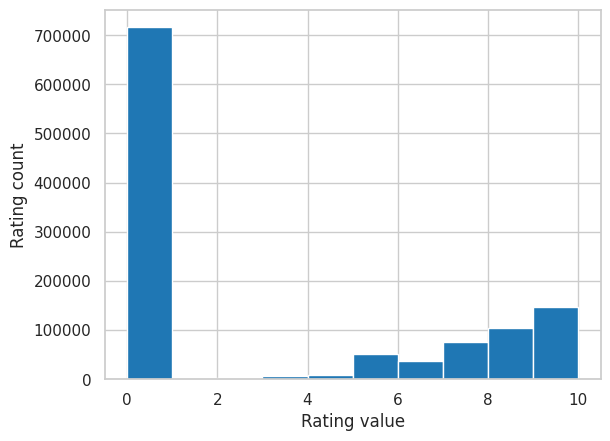

In [446]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")

ratings["Book-Rating"].hist()
plt.xlabel("Rating value")
plt.ylabel("Rating count")
plt.show()


Теперь посмотрим на таблицу `Books`.

In [447]:
books = pd.read_csv("Books.csv")
books.head()

<ipython-input-447-7dc4eb500039>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [448]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


- Есть немножко пропусков.
- Проверим уязвимую часть данных – года – на адекватность.

In [449]:
books["Year-Of-Publication"].value_counts().sort_values(ascending=True)[:10]

,count
Year-Of-Publication,
2037,1
2011,1
2038,1
1938,1
1906,1
1919,1
1926,1
1926,1
2008,1


Есть года, которые еще не наступили...

Проверим, есть ли строковые данные в столбце с годом (потому что `info()` назвал тип данных столбца `object`).

In [450]:
books[books["Year-Of-Publication"].map(str).str.match("[^0-9]")]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


В трех строках пропущен автор, из-за чего смещены данные. Автор либо пропущен, либо склеен с названием. Надо проверить.

В сводке написано, что часть авторов и издателей провущена. Проверим, так ли это.

In [451]:
books[(books["Book-Author"].isnull()) | (books["Publisher"].isnull())]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...


Да, это так. Основные проблемы с данными выявили. Пора их исправлять и приступать к созданию рекомендаций.

## План анализа данных

1. Обработать данные, т.к. в данных есть несколько небольших проблем:
  1. В паре строк в таблице `Books.scv` значения столбцов сдвинуты вправо, а еще есть года, которые еще не наступили.
  2. В нескольких строках в таблице `Books.scv` есть пропуски, а также для рекомендаций в рамках лабораторной не понадобятся ссылки на картинки с обложкой.
  3. Не будем использовать для обучения записи с рейтинг равным 0 из таблицы `Ratings.scv`. Считаем, что 0 означает, что пользователь еще не оценивал книгу, но проявил к ней какой-то интерес.
  4. Не будем использовать для обучения алгоритмов те книги, которым оценка поставлена всего 1 раз. Пользователей, оценивших всего одну книгу тоже брать в расчет не будем (хотя это на самом деле будет не сильно сказываться на обобщающей способности алгоритмов, можете сами проверить).
  5. Пункты 1-4 необходимы и достаточны для выполнения всех задач. Но можно сделать более глубокую обработку.
2. Обучить [SVD](https://surprise.readthedocs.io/en/stable/getting_started.html) на следующих записях: у книги есть хотя бы одна оценка, пользователь оценил хотя бы одну книгу.
   - МАЕ должно быть ниже 1.3 (для этого есть тест)
   - **Сохранить модель.**
3. Научить линейную регрессию ([SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)) предсказывать средний рейтинг книги по следующим столбцам: автор, издатель, год издания, векторизованное название (для векторизации можно использовать [tf-idf](https://scikit-learn.org/stable/modules/feature_extraction.html#tfidf-term-weighting), [word2vec](https://radimrehurek.com/gensim/models/word2vec.html) или более сложный алгоритм. Для достижения требуемой тестом точности достаточно будет tf-idf. Собрав полностью датасет, не забудьте нормализовать данные ([StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)).
   - МАЕ должно быть ниже 1.5 (для этого есть тест)
   - **Сохранить модель.**
4. В файле `personal_recommendation.py` создайте рекомендацию для пользователя, у которого в исходном датасете было больше всего 0 среди рейтингов книг.
   Алгоритм такой:
   1. Находим нужного пользователя.
   2. Делаем предсказание SVD для книг, которым он "поставил" 0.
   3. Берем те книги, для которых предсказали рейтинг не ниже 8. Считаем, что 8 означет, что книга ему точно понравится.
   4. Делаем предсказание LinReg для этих же книг.
   5. Сортируем полученный на шаге 3 список по убыванию рейтинга линейной модели.
   6. В конце файла комментарием записываем полученную рекомендацию.

- То есть идея в том, чтобы сделать для пользователя индивидуальную рекомендацию, показывая в начале списка те книги, которые в целом могли бы иметь высокий рейтинг.
- Обязательно сохраняйте готовую модель и добавляйте ее в свой репозиторий, потому что файл с сохраненной моделью используется в тестах.

## Обработка данных

In [452]:
books = books[books["Year-Of-Publication"].astype(str).str.match("^\d+$")]
books = books[books["Year-Of-Publication"].astype(int) <= 2020]
books = books.dropna(subset=["Book-Author", "Publisher"])
books = books.drop(columns=["Image-URL-S", "Image-URL-M", "Image-URL-L"])

In [453]:
ratings = ratings[ratings["Book-Rating"] > 0]
ratings = ratings[ratings["User-ID"].isin(ratings["User-ID"].value_counts()[ratings["User-ID"].value_counts() > 1].index)]
ratings = ratings[ratings["ISBN"].isin(ratings["ISBN"].value_counts()[ratings["ISBN"].value_counts() > 1].index)]

In [454]:
books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company
...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm)
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press


In [455]:
ratings

,User-ID,ISBN,Book-Rating
16,276747,0060517794,9
19,276747,0671537458,9
20,276747,0679776818,8
33,276762,0380711524,5
44,276762,3453092007,8
...,...,...,...
1149745,276688,0892966548,10
1149746,276688,1551669315,6
1149761,276704,0345386108,6
1149771,276704,0743211383,7


## SVD

In [456]:
users_with_ratings = ratings['User-ID'].unique()
ratings = ratings[ratings['User-ID'].isin(users_with_ratings)]

In [457]:
from surprise import Dataset
from surprise import Reader

reader = Reader(rating_scale=(1, 10))

data = Dataset.load_from_df(ratings[['User-ID', 'ISBN', 'Book-Rating']], reader)

In [458]:
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

trainset, testset = train_test_split(data, test_size=0.2)

model = SVD()
model.fit(trainset)

predictions = model.test(testset)

accuracy.mae(predictions)

MAE:  1.2514


1.2513766676457079

In [459]:
import joblib

joblib.dump(model, 'svd_model.pkl')

['svd_model.pkl']

## SGDRegressor

In [460]:
# !pip install scikit-learn
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

In [461]:
books = pd.read_csv("Books.csv")
ratings = pd.read_csv("Ratings.csv")

<ipython-input-461-89054bd451d0>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv")


In [462]:
ratings = ratings[ratings['Book-Rating'] > 0]
avg_ratings = ratings.groupby('ISBN')['Book-Rating'].mean().reset_index()
avg_ratings.rename(columns={'Book-Rating': 'Average-Rating'}, inplace=True)

In [463]:
df_merged = pd.merge(books, avg_ratings, on='ISBN')
df_merged.dropna(subset=['Book-Author', 'Publisher', 'Year-Of-Publication', 'Book-Title', 'Average-Rating'], inplace=True)

In [464]:
df_merged['Year-Of-Publication'] = pd.to_numeric(df_merged['Year-Of-Publication'], errors='coerce')

In [465]:
df_merged['Year-Of-Publication'].replace(0, pd.NA, inplace=True)
df_merged['Year-Of-Publication'].fillna(df_merged['Year-Of-Publication'].median(), inplace=True)

<ipython-input-465-d488f8770fa0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['Year-Of-Publication'].replace(0, pd.NA, inplace=True)
<ipython-input-465-d488f8770fa0>:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['Year-Of-Publication'].fillna(df_merged['Year-Of-Publication'].median(), 

In [466]:
X = df_merged[['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication']]
y = df_merged['Average-Rating']

In [467]:
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
one_hot = ColumnTransformer(transformers=[
    ('author', OneHotEncoder(handle_unknown='ignore'), ['Book-Author']),
    ('publisher', OneHotEncoder(handle_unknown='ignore'), ['Publisher'])
], remainder='drop')

scaler = StandardScaler()


preprocessor = ColumnTransformer(transformers=[
    ('title', tfidf, 'Book-Title'),
    ('author_publisher', one_hot, ['Book-Author', 'Publisher']),
    ('year', scaler, ['Year-Of-Publication'])
])

In [468]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(random_state=42, max_iter=5000, tol=1e-3))
])


In [469]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('title',
                                                  TfidfVectorizer(max_features=10000,
                                                                  stop_words='english'),
                                                  'Book-Title'),
                                                 ('author_publisher',
                                                  ColumnTransformer(transformers=[('author',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['Book-Author']),
                                                                                  ('publisher',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['Publisher'])]),
                                                  ['Book-Author', 'Publisher']),
                                                 ('year', StandardScaler(),
                                                  ['Year-Of-Publication'])])),
                ('regressor', SGDRegressor(max_iter=5000, random_state=42))])

In [470]:
y_pred = pipeline.predict(X_test)
mean_absolute_error(y_test, y_pred)

1.3189871592243398

In [471]:
with open('sgd_regressor_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('onehot_encoder.pkl', 'wb') as f:
    pickle.dump(one_hot, f)

with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## Персональная рекомендация

In [472]:
import numpy as np
import pandas as pd
from surprise import SVD, Reader, Dataset
from surprise.model_selection import train_test_split as surprise_train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from joblib import load, dump
from sklearn.model_selection import train_test_split

In [473]:
ratings = pd.read_csv("Ratings.csv")
books = pd.read_csv("Books.csv", dtype={'Year-Of-Publication': str}, low_memory=False)

In [474]:
null_ratings = ratings[ratings['Book-Rating'] == 0]
user_counts = null_ratings['User-ID'].value_counts()
most_nulls = user_counts.idxmax()

In [475]:
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings[['User-ID', 'ISBN', 'Book-Rating']], reader)
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

In [476]:
svd_model = load("svd_model.pkl")

In [477]:
user_null_ratings = null_ratings[null_ratings['User-ID'] == most_nulls]
isbn_list = user_null_ratings['ISBN'].tolist()

predictions_svd = [(isbn, svd_model.predict(most_nulls, isbn).est) for isbn in isbn_list]

In [478]:
recommendations_svd = [isbn for isbn, rating in predictions_svd if rating >= 8]

In [479]:
avg_ratings = ratings.groupby('ISBN')['Book-Rating'].mean().reset_index().rename(columns={'Book-Rating': 'Average-Rating'})
df_merged = pd.merge(books, avg_ratings, on='ISBN')

In [480]:
personal_recommendations = df_merged[df_merged['ISBN'].isin(recommendations_svd)]

In [481]:
X = personal_recommendations[['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication']]
y = personal_recommendations['Average-Rating']

In [482]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
one_hot = ColumnTransformer(transformers=[
    ('author', OneHotEncoder(handle_unknown='ignore'), ['Book-Author']),
    ('publisher', OneHotEncoder(handle_unknown='ignore'), ['Publisher'])
], remainder='drop')

scaler = StandardScaler()

In [483]:
preprocessor = ColumnTransformer(transformers=[
    ('title', tfidf, 'Book-Title'),
    ('author_publisher', one_hot, ['Book-Author', 'Publisher']),
    ('year', scaler, ['Year-Of-Publication'])
])

In [484]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SGDRegressor(random_state=42, max_iter=1000, tol=1e-3))
])

In [485]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('title',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'Book-Title'),
                                                 ('author_publisher',
                                                  ColumnTransformer(transformers=[('author',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['Book-Author']),
                                                                                  ('publisher',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['Publisher'])]),
                                                  ['Book-Author', 'Publisher']),
                                                 ('year', StandardScaler(),
                                                  ['Year-Of-Publication'])])),
                ('regressor', SGDRegressor(random_state=42))])

In [486]:
y_pred = pipeline.predict(X_test)
y_pred = np.clip(y_pred, 1, 10)

In [487]:
predictions_linreg = pipeline.predict(personal_recommendations[['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication']])
predictions_linreg = np.clip(predictions_linreg, 1, 10)

In [488]:
personal_recommendations['Predicted-Rating'] = predictions_linreg
personal_recommendations_sorted = personal_recommendations.sort_values(by='Predicted-Rating', ascending=False)[
    ['Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication', 'Predicted-Rating']
]

<ipython-input-488-bf7e3dd604d7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  personal_recommendations['Predicted-Rating'] = predictions_linreg


In [489]:
dump(pipeline, "recommendations.joblib")

personal_recommendations_sorted.head()

,Book-Title,Book-Author,Publisher,Year-Of-Publication,Predicted-Rating
900,The Magician's Nephew (Narnia),C. S. Lewis,HarperTrophy,1994,5.527872
4461,Love You Forever,Robert N. Munsch,Firefly Books Ltd,1986,5.295344
24282,"The Lion, the Witch and the Wardrobe (Full-Col...",C. S. Lewis,HarperTrophy,2000,5.145923
18996,The Biggest Pumpkin Ever,Steven Kroll,Cartwheel Books,1993,4.894193
3842,Charlotte's Web (Trophy Newbery),E. B. White,HarperTrophy,1974,4.449768


## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе есть два теста – на качество получившихся моделей.
- Пул-реквест нужно сделать в ветку `lab2`.
- Можно загрузить в гитхаб файлы с реализацией по шаблону (шаблон можно дополнять и изменять под себя) или подготовить колаб с решением. Главное – сохранить модели, тесты проверяют их.

> Будьте внимательны! На гитхабе в ветке `main` обновился файл `pyad.yml`.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**